In [1]:
import numpy as np
import feature_engineering_scaling as fes
from tensorflow.keras.models import load_model

2024-12-14 14:47:49.133848: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-14 14:47:49.850042: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-14 14:47:51.573141: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from tensorflow.keras.utils import to_categorical

In [3]:
# Load the saved models
model = load_model("model_ann_both_chains_together.h5")  # Model for classifying 0, 1, 2, 3

2024-12-14 14:48:31.419485: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [4]:
df = fes.df

In [5]:
X = df[['energy', 'r', 'z', 'time_diff', 'distance']]
y = df['truth']

In [6]:
# Further split using train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

In [7]:
# Step 3: Predict probabilities on the unseen data
y_pred = model.predict(X_test)  # Probabilities for [0, 1, 2, 3]

2024-12-14 14:48:37.280961: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 257721320 exceeds 10% of free system memory.


201345/201345 [==============================] - 446s 2ms/step


2024-12-14 14:58:32.636746: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 154632792 exceeds 10% of free system memory.


In [8]:
from sklearn.metrics import confusion_matrix, classification_report

In [9]:
# Convert probabilities to class labels using argmax
y_pred = np.argmax(y_pred, axis=1)

In [10]:
# Step 7: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

In [11]:
# Step 8: Print the classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:


              precision    recall  f1-score   support

         0.0       0.93      0.66      0.77   1077390
         1.0       0.50      0.31      0.39   1083366
         2.0       0.92      0.94      0.93   1083857
         3.0       0.56      0.83      0.67   1077467
         4.0       0.49      0.57      0.52   1060580
         5.0       0.93      0.92      0.93   1060373

    accuracy                           0.71   6443033
   macro avg       0.72      0.71      0.70   6443033
weighted avg       0.72      0.71      0.70   6443033



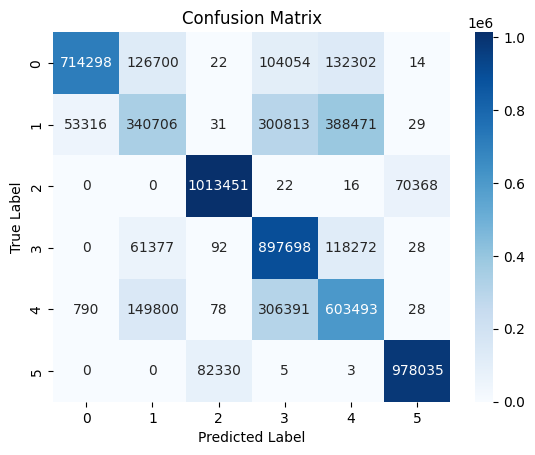

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 9: Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [13]:
# Min-Max Unscaling Function
def minmax_unscaler(X_unscaled, X_scaled, columns):
    """
    Unscale X_test using the min and max values derived from the original X data.
    
    Parameters:
    - X_unscaled: Original (unscaled) data.
    - X_scaled: Scaled data (after MinMaxScaler).
    - columns: List of columns to be unscaled.
    
    Returns:
    - X_scaled: DataFrame with columns unscaled.
    """
    min_vals = X_unscaled[columns].min()
    max_vals = X_unscaled[columns].max()
    
    # Formula for unscaling using MinMax: 
    # unscaled_value = scaled_value * (max - min) + min
    X_scaled[columns] = X_scaled[columns] * (max_vals - min_vals) + min_vals
    
    return X_scaled

In [ ]:
# Robust Unscaling Function
def robust_unscaler(X_unscaled, X_scaled, columns):
    """
    Unscale X_test using the median and IQR derived from the original X data.
    
    Parameters:
    - X_unscaled: Original (unscaled) data.
    - X_scaled: Scaled data (after RobustScaler).
    - columns: List of columns to be unscaled.
    
    Returns:
    - X_scaled: DataFrame with columns unscaled.
    """
    median_vals = X_unscaled[columns].median()
    iqr_vals = X_unscaled[columns].quantile(0.75) - X_unscaled[columns].quantile(0.25)
    
    # Formula for unscaling using RobustScaler:
    # unscaled_value = scaled_value * IQR + median
    X_scaled[columns] = X_scaled[columns] * iqr_vals + median_vals
    
    return X_scaled

: 

In [ ]:
# For MinMaxScaler unscaling
columns_minmax = ['energy', 'r']  # Columns you scaled with MinMaxScaler
X_test_unscaled_minmax = minmax_unscaler(fes.X, X_test.copy(), columns_minmax)


In [ ]:

# For RobustScaler unscaling
columns_robust = ['z', 'time_diff']  # Columns you scaled with RobustScaler
X_test_unscaled_robust = robust_unscaler(fes.X, X_test.copy(), columns_robust)


In [ ]:
X_test.describe()

,energy,r,z,time_diff,distance
161298,0.652061,0.742802,0.850975,-0.261900,7.000387
284920,0.221756,0.767067,-0.777154,1.708053,7.810701
239955,0.089942,0.742485,-0.511738,-0.298053,4.202520
101486,0.080771,0.604453,0.031611,-0.298046,3.729707
146809,0.085857,0.537318,0.306146,-0.298053,3.919498


In [ ]:
X_test.head()

,energy,r,z,time_diff,distance
161298,0.652061,0.742802,0.850975,-0.261900,7.000387
284920,0.221756,0.767067,-0.777154,1.708053,7.810701
239955,0.089942,0.742485,-0.511738,-0.298053,4.202520
101486,0.080771,0.604453,0.031611,-0.298046,3.729707
146809,0.085857,0.537318,0.306146,-0.298053,3.919498


In [ ]:
X_test_unscaled_robust

,energy,r,z,time_diff,distance
161298,0.652061,0.742802,1342.010753,3.994270e-01,7.000387
284920,0.221756,0.767067,-1225.027710,2.216369e+01,7.810701
239955,0.089942,0.742485,-806.552440,5.066395e-07,4.202520
101486,0.080771,0.604453,50.134591,7.890072e-05,3.729707
146809,0.085857,0.537318,482.989442,1.043081e-07,3.919498
...,...,...,...,...,...
212636,0.071150,0.740012,982.855457,4.550070e-05,3.926524
225062,0.201816,0.656551,-189.775007,1.662708e+01,7.946851
220695,0.094229,0.605605,1269.302936,1.505651e+01,7.590328
17223,0.207601,0.239764,-1224.583309,9.306844e+00,6.755855


In [ ]:
# Reset the index of each DataFrame
X_test_unscaled_minmax = X_test_unscaled_minmax.reset_index(drop=True)
X_test_unscaled_robust = X_test_unscaled_robust.reset_index(drop=True)
X_test= X_test.reset_index(drop=True)

# Now concatenate the DataFrames
combined_df = pd.concat([
    X_test_unscaled_minmax[['energy', 'r']],  # Columns from MinMax unscaled data
    X_test_unscaled_robust[['z', 'time_diff']],  # Columns from Robust unscaled data
    X_test[['distance']]  # 'distance' column from original X data
], axis=1)

In [ ]:
combined_df.head()

,energy,r,z,time_diff,distance
0,6.648689,1386.556709,1342.010753,3.994270e-01,7.000387
1,2.261120,1431.849637,-1225.027710,2.216369e+01,7.810701
2,0.917085,1385.965179,-806.552440,5.066395e-07,4.202520
3,0.823574,1128.316217,50.134591,7.890072e-05,3.729707
4,0.875433,1003.003778,482.989442,1.043081e-07,3.919498


In [ ]:
# To unscale back to original:
combined_df['distance'] = np.expm1(combined_df['distance'])  # Inverse of log1p

In [ ]:
combined_df.head()

,energy,r,z,time_diff,distance
0,6.648689,1386.556709,1342.010753,3.994270e-01,1096.057270
1,2.261120,1431.849637,-1225.027710,2.216369e+01,2465.858184
2,0.917085,1385.965179,-806.552440,5.066395e-07,65.854587
3,0.823574,1128.316217,50.134591,7.890072e-05,40.666910
4,0.875433,1003.003778,482.989442,1.043081e-07,49.375149


In [ ]:
# Plot histograms for individual models and final predictions
def plot_histograms(X, predictions, model_name, feature_names):
    """
    Plots histograms for each feature and each predicted class separately.

    Parameters:
        X (numpy array or pandas DataFrame): Feature data.
        predictions (numpy array): Predicted class labels.
        model_name (str): Name of the model (for plot titles).
        feature_names (list of str): Names of the features.
    """
    # Ensure X is a NumPy array
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()

    for feature_idx, feature_name in enumerate(feature_names):
        for class_label in np.unique(predictions):
            plt.figure(figsize=(10, 6))
            
            # Filter the data for the current class
            class_data = X[predictions == class_label, feature_idx]
            
            # Plot histogram for the current feature and class
            plt.hist(class_data, bins=500, alpha=0.7, color='blue')
            plt.title(f'Histogram of {feature_name} (Class {class_label}) - {model_name}')
            plt.xlabel(feature_name)
            plt.ylabel('Frequency')
            plt.grid(True)
            plt.show()

In [ ]:
# Feature names
feature_names = ['energy', 'r', 'z', 'time_diff', 'distance']

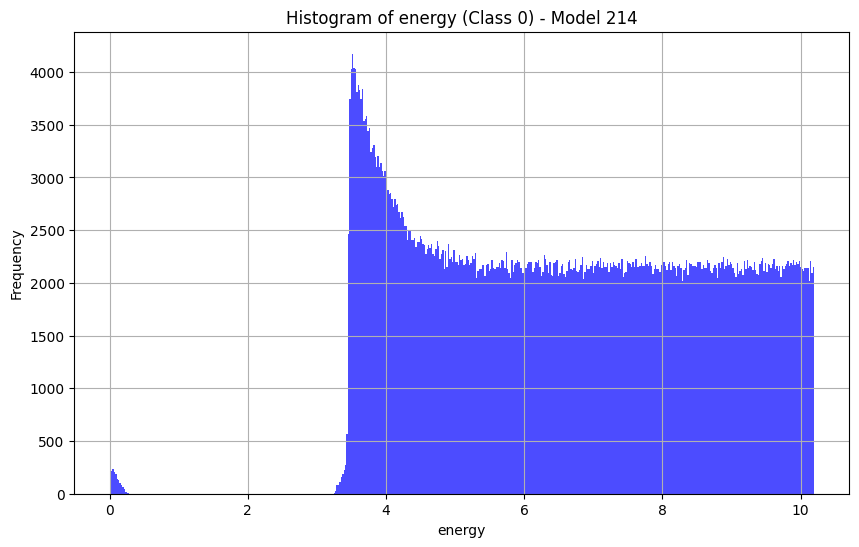

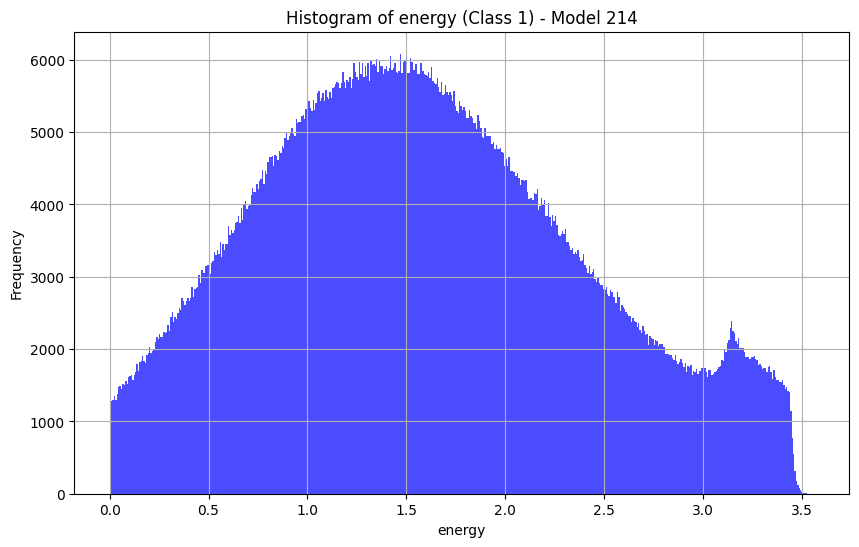

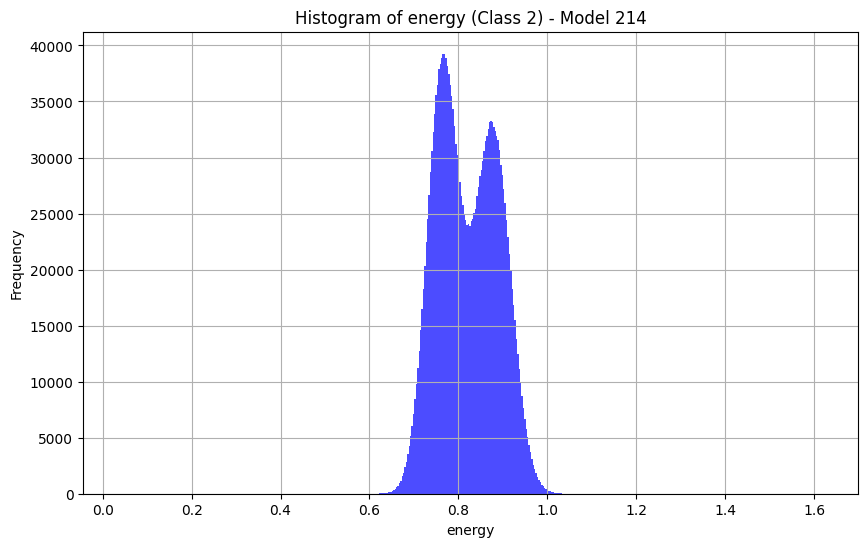

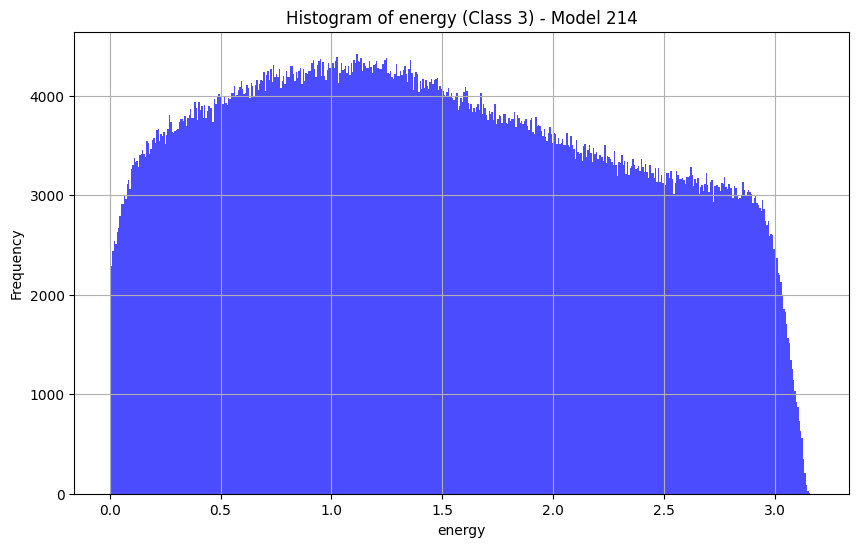

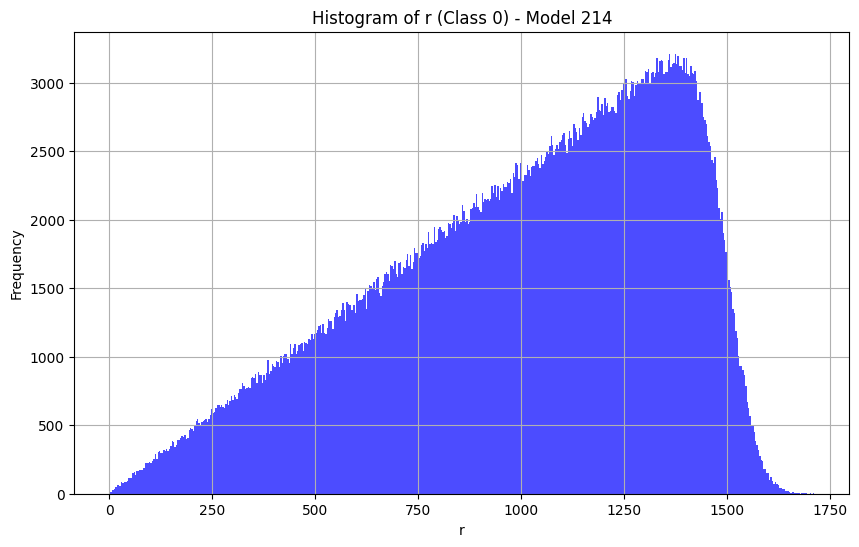

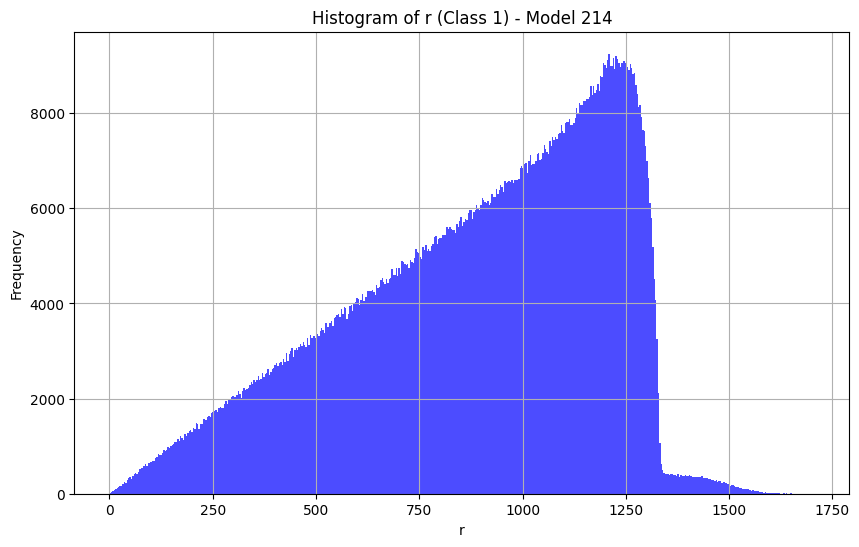

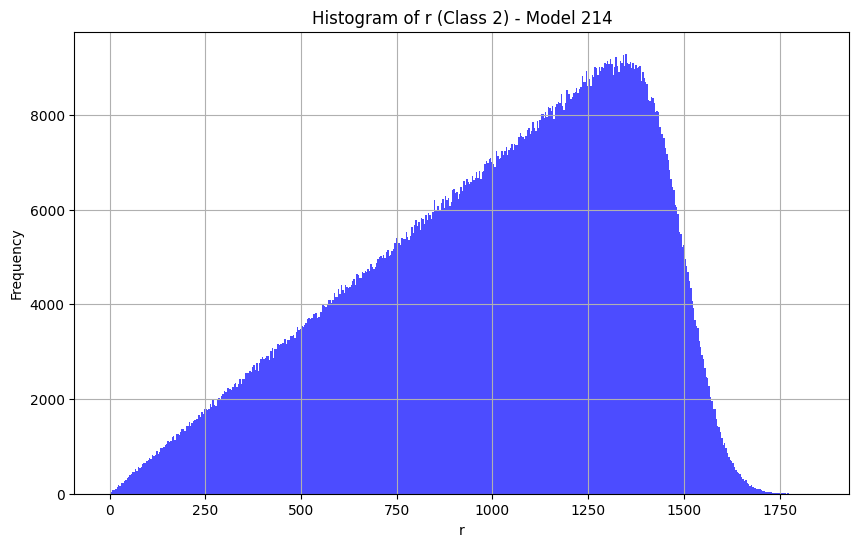

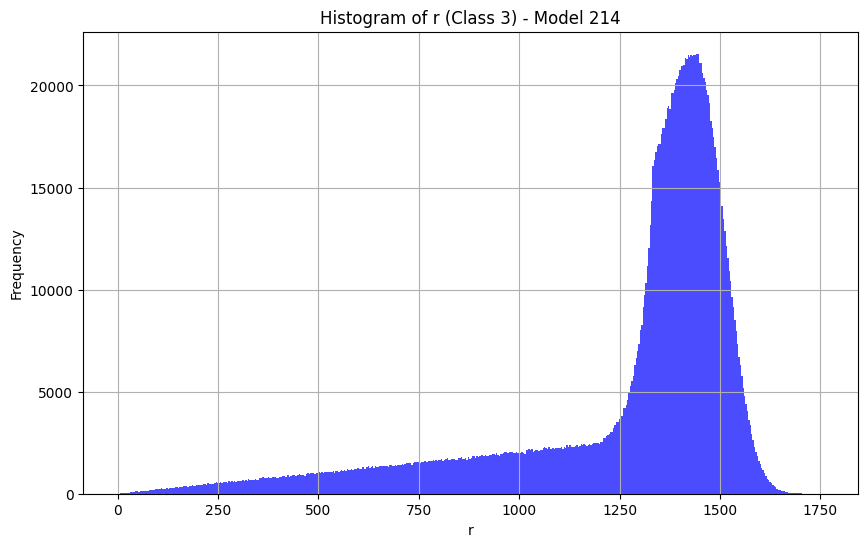

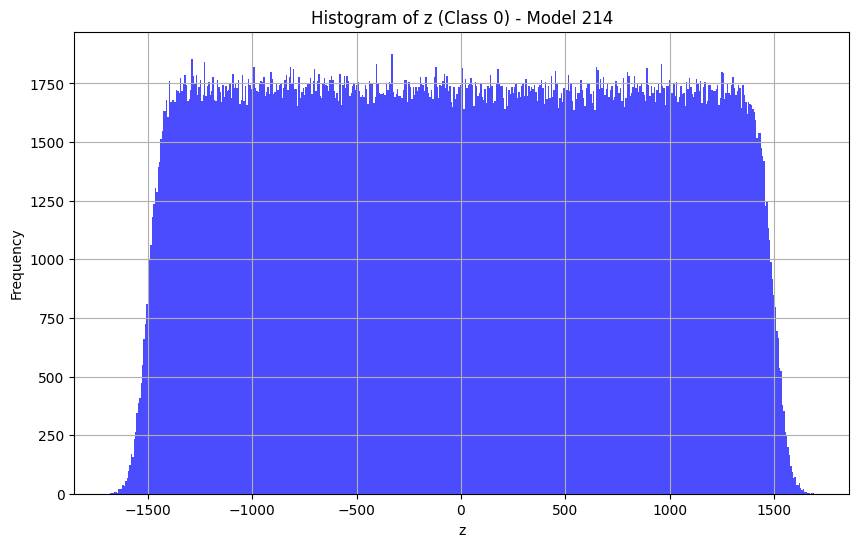

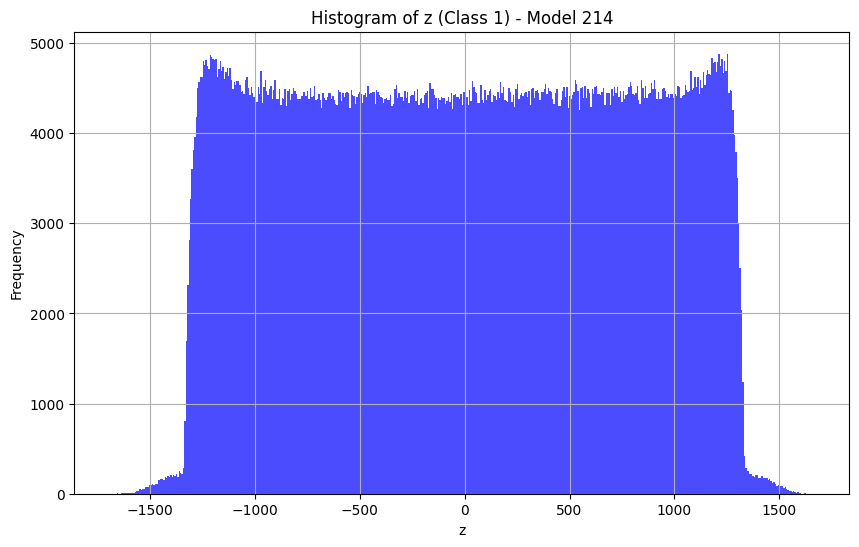

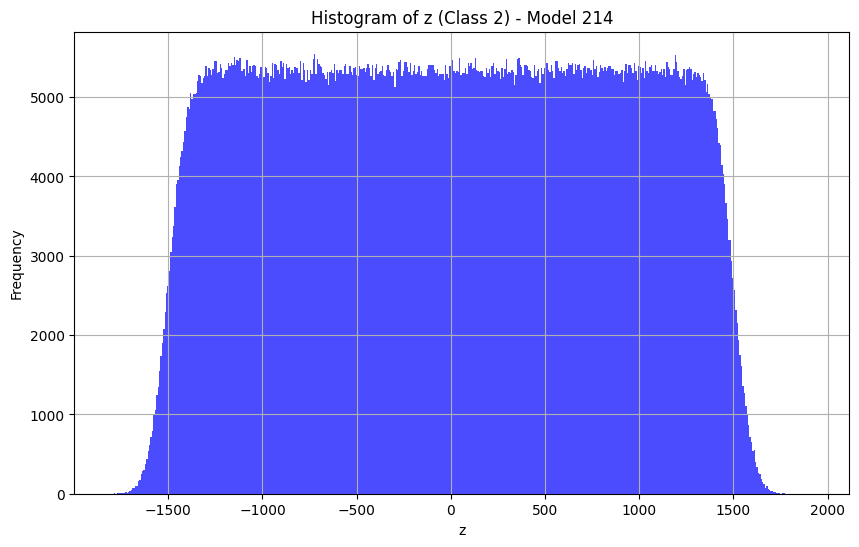

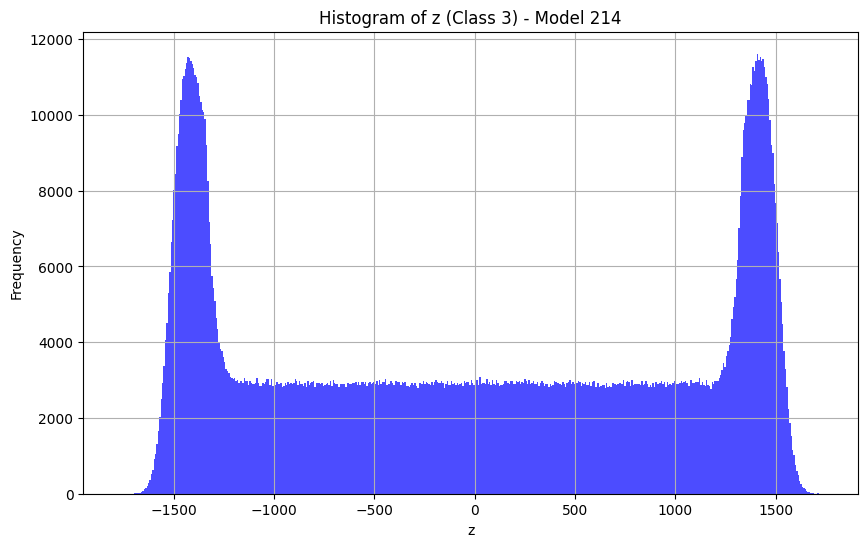

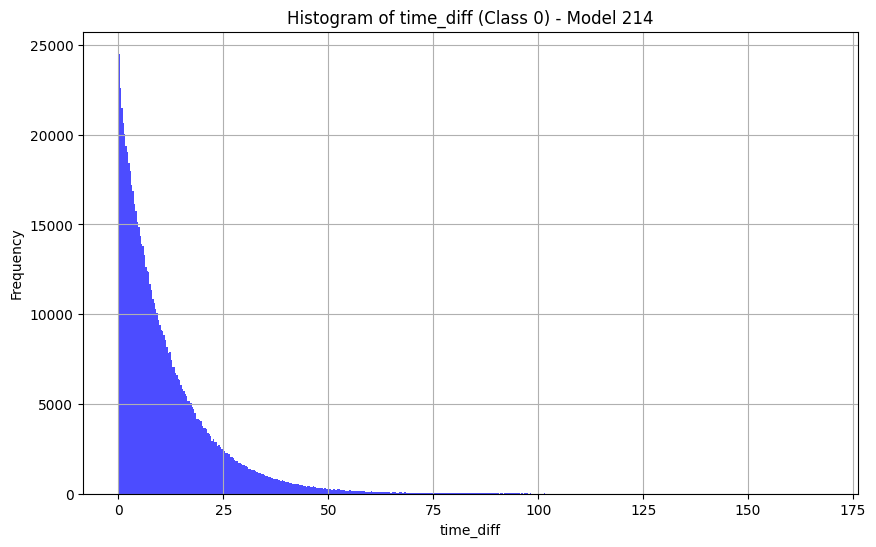

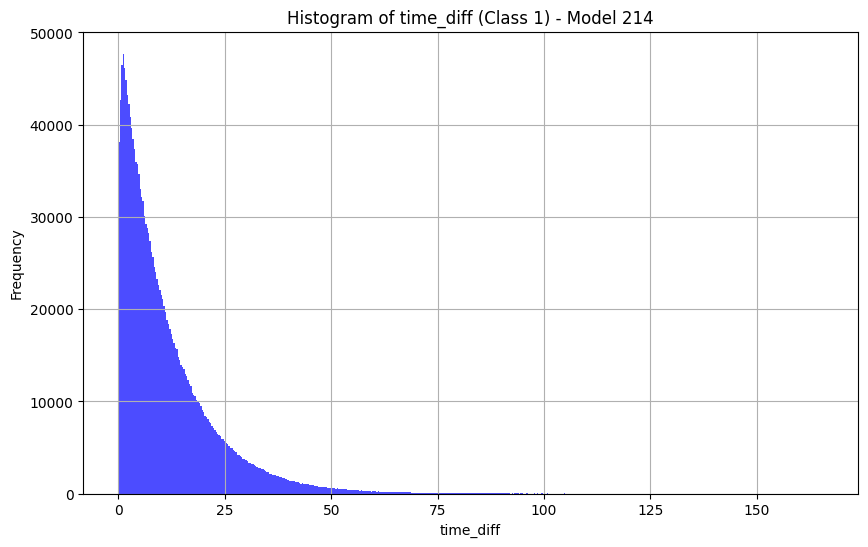

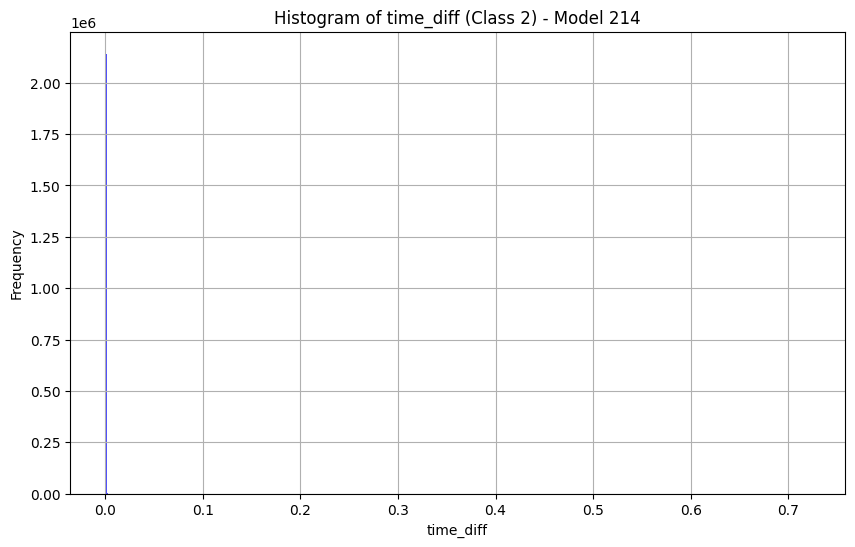

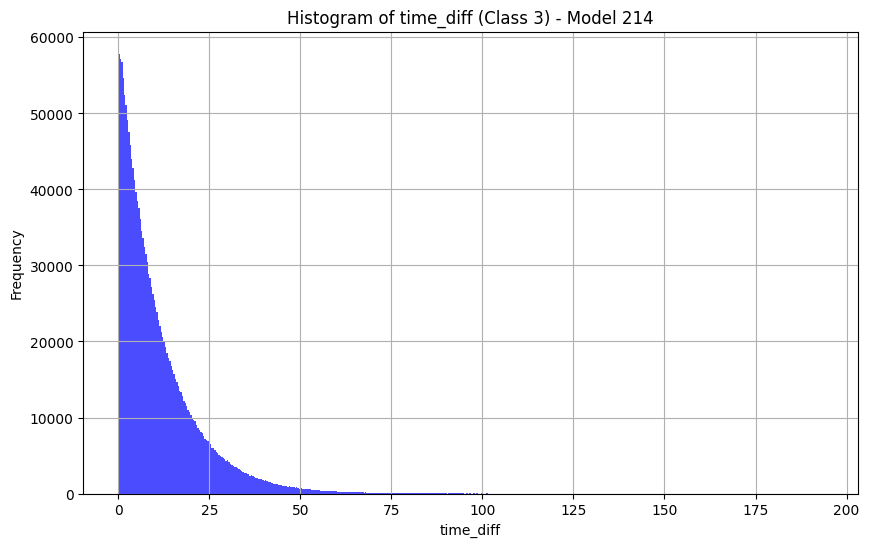

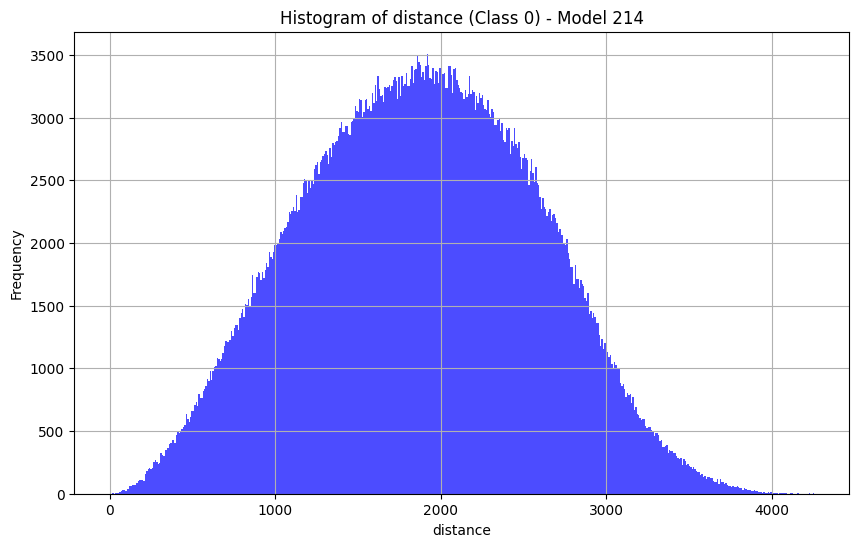

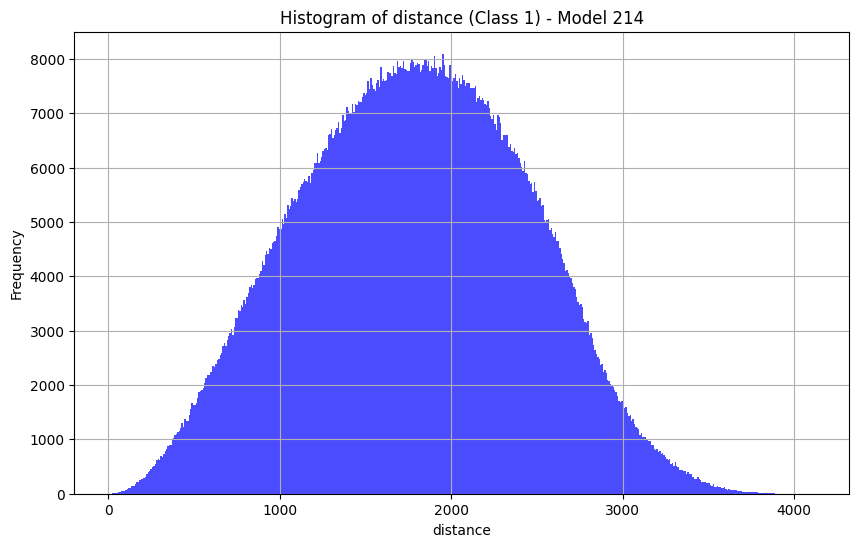

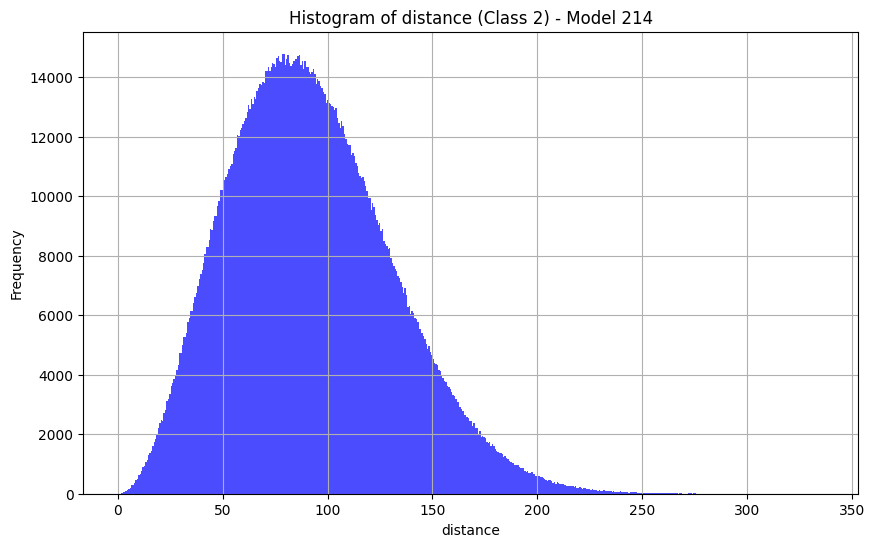

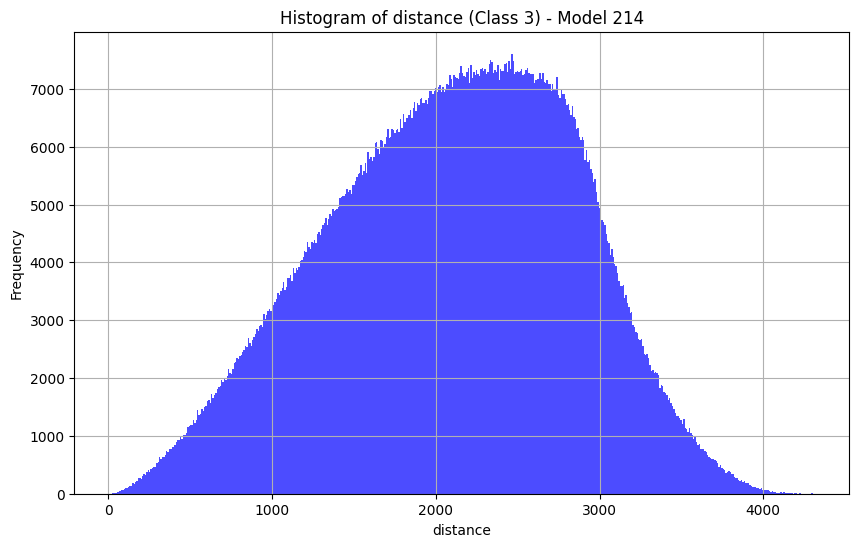

In [ ]:
# Plot for model_1_2
plot_histograms(combined_df, y_pred, "Model wit both chains", feature_names)

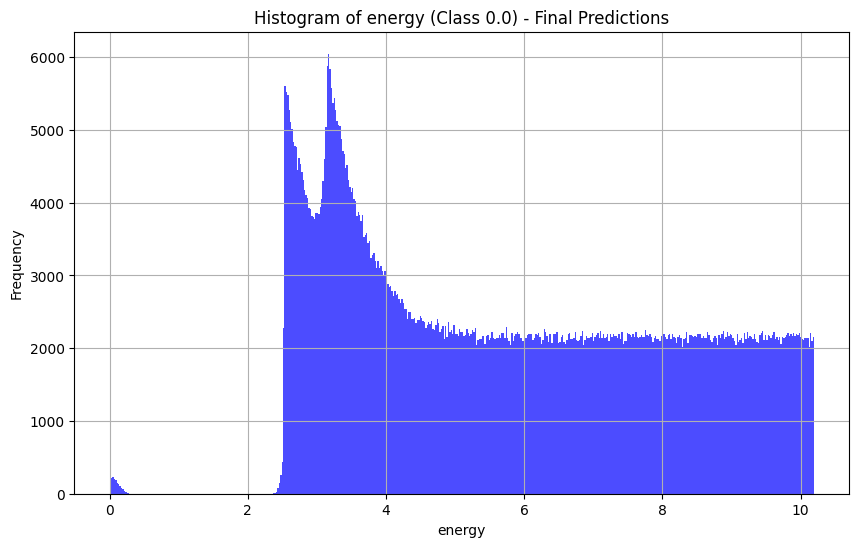

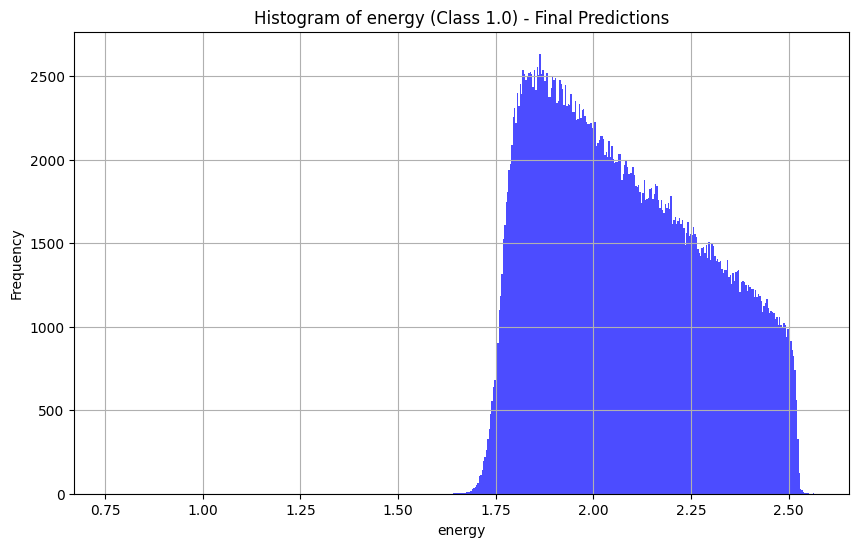

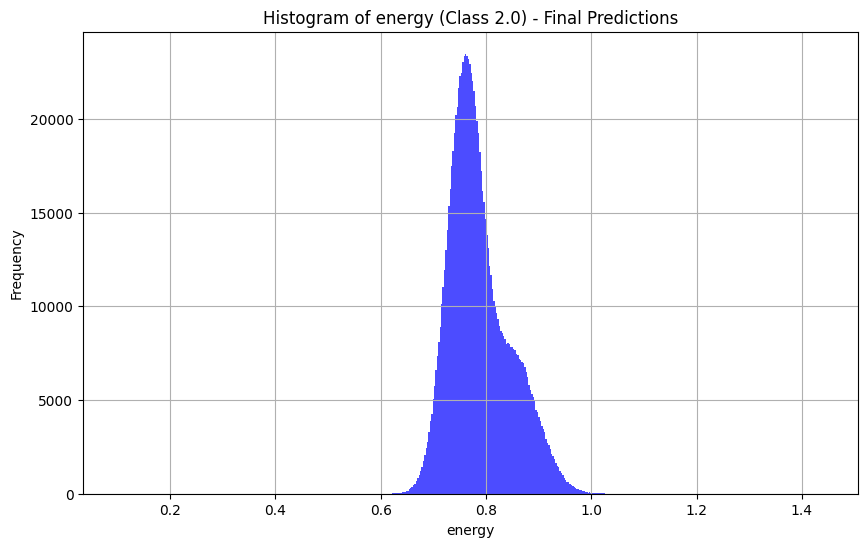

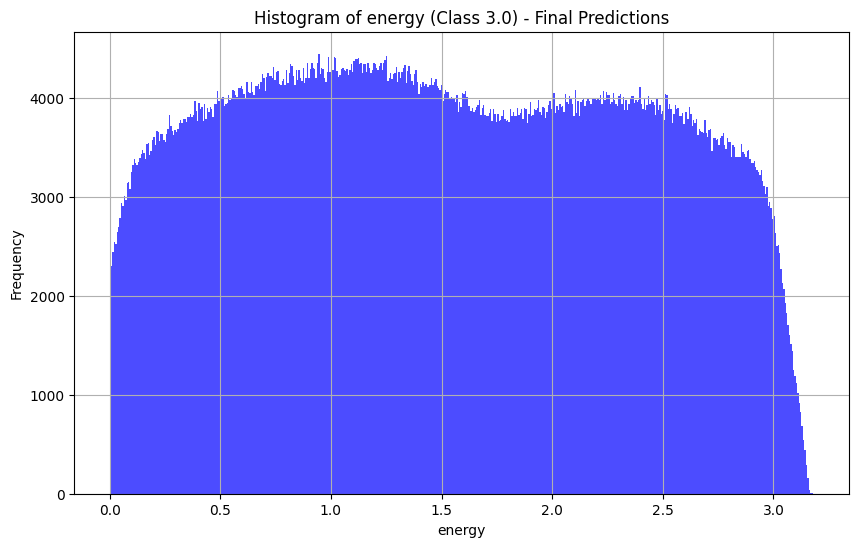

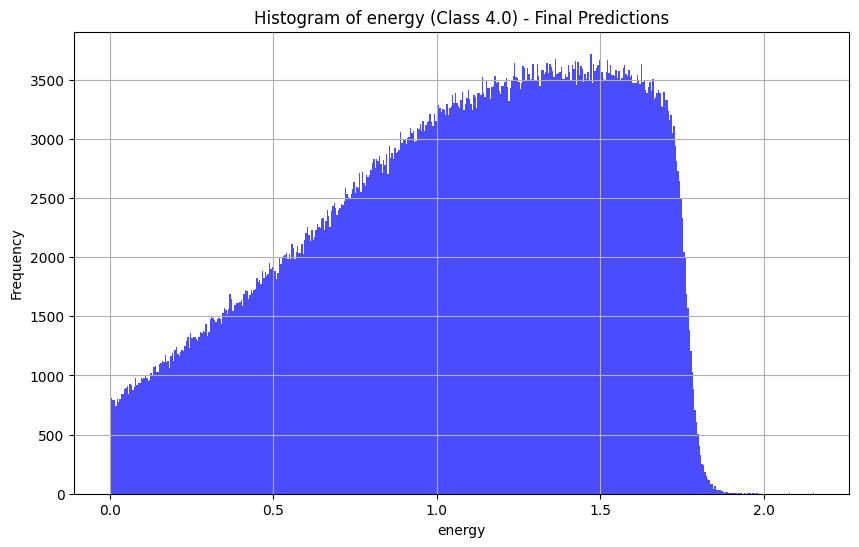

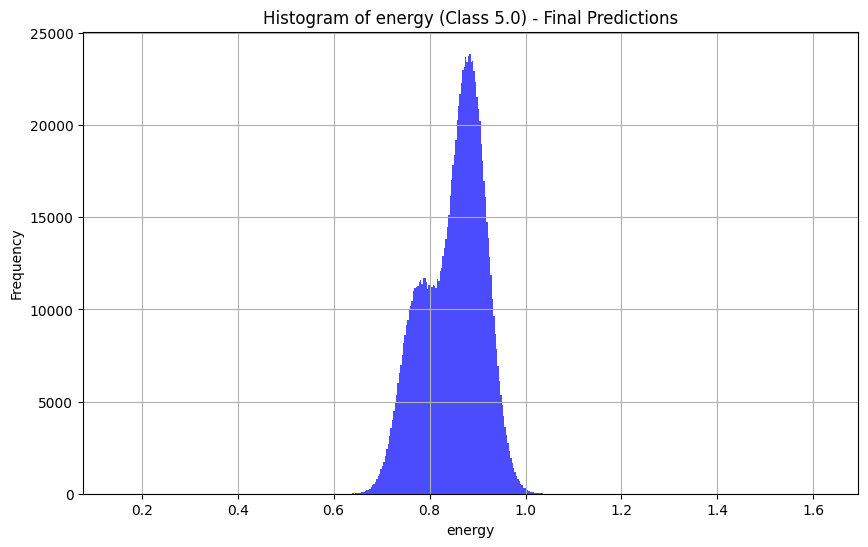

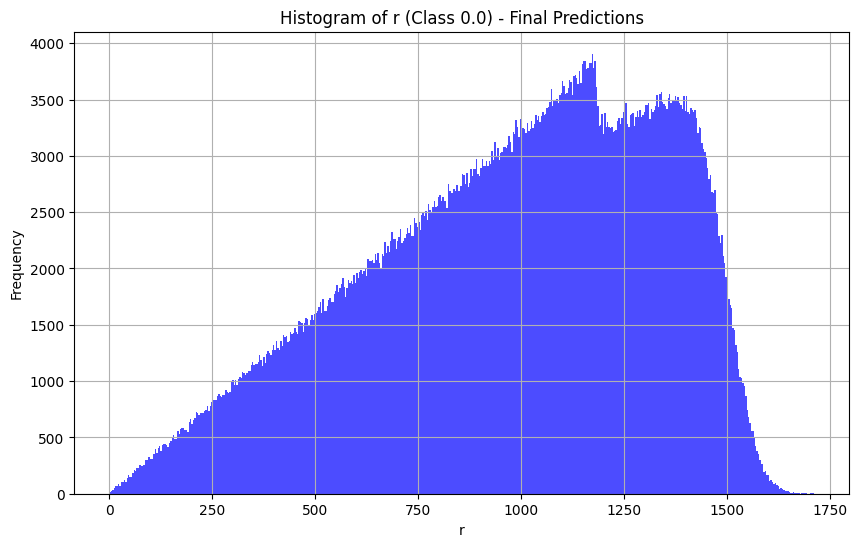

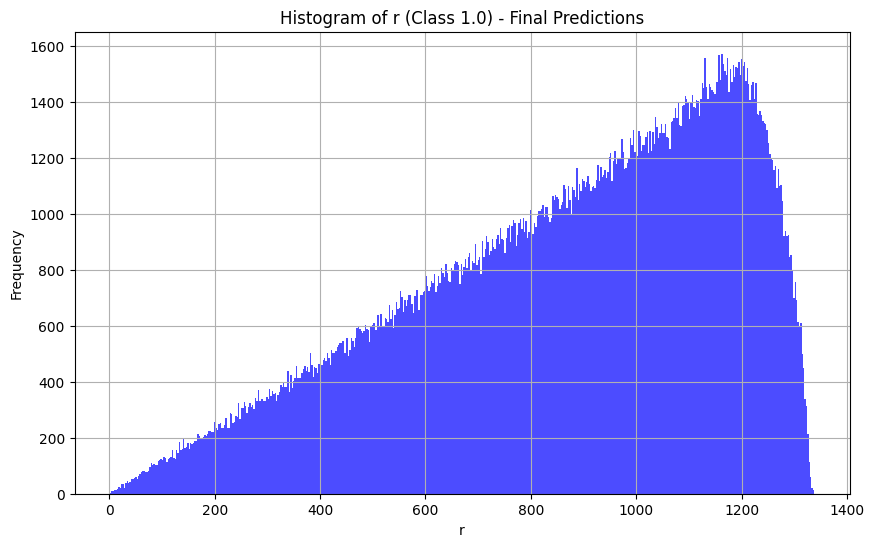

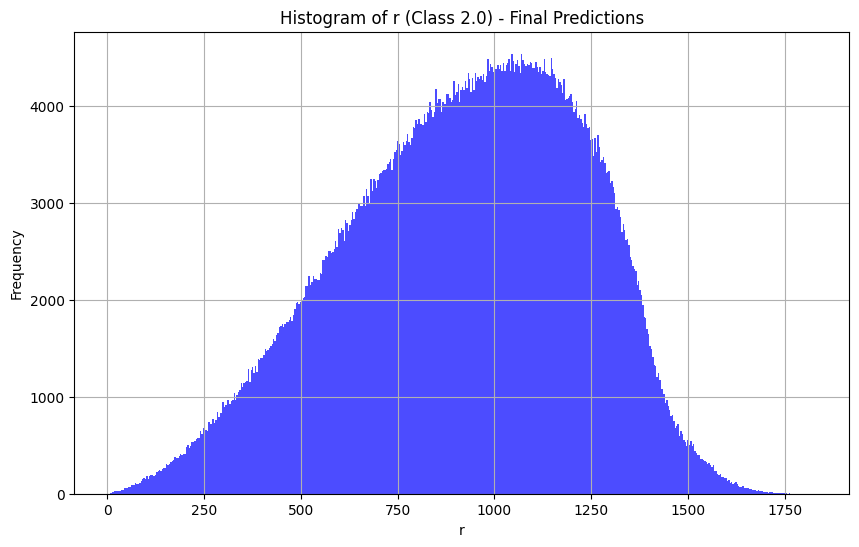

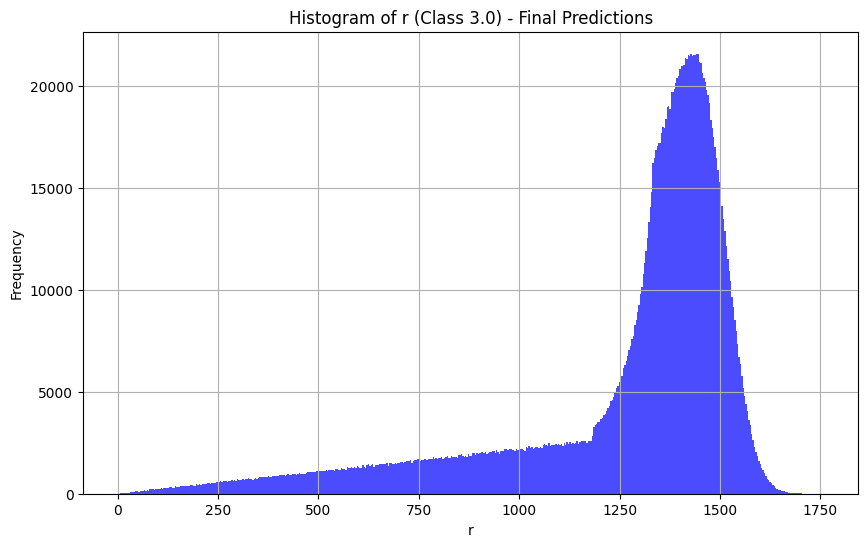

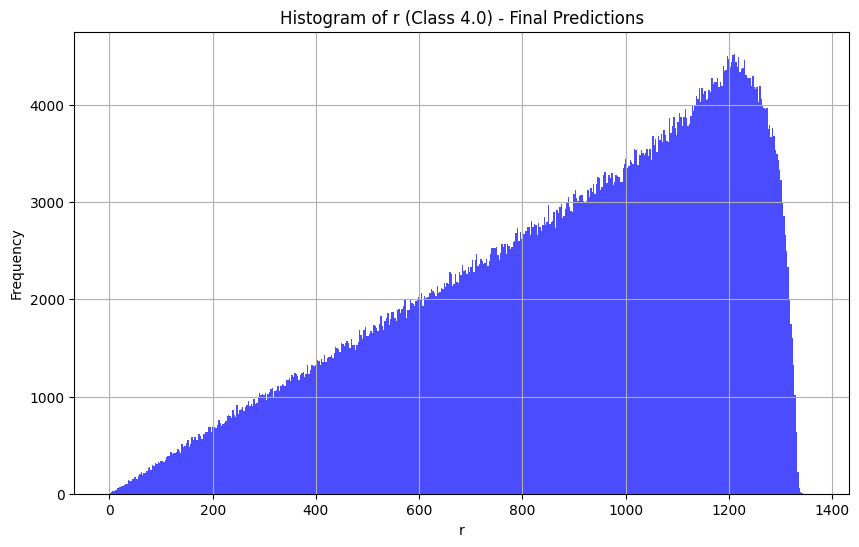

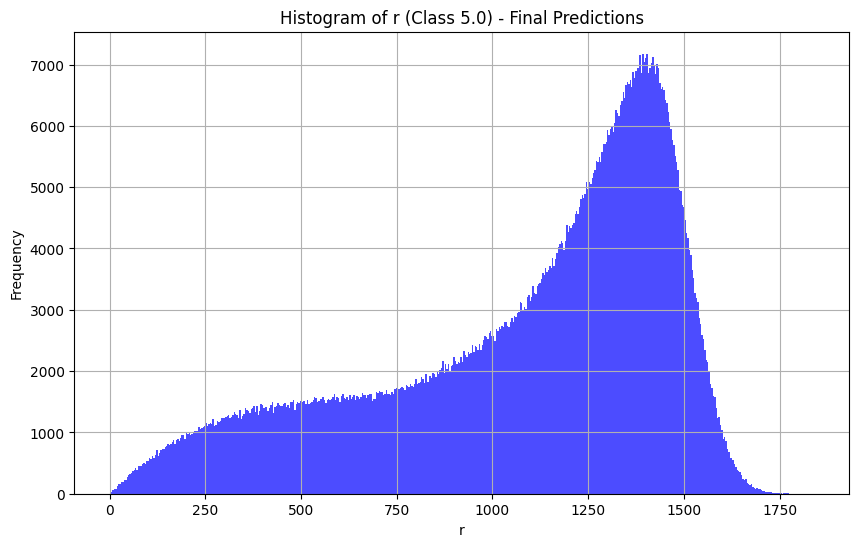

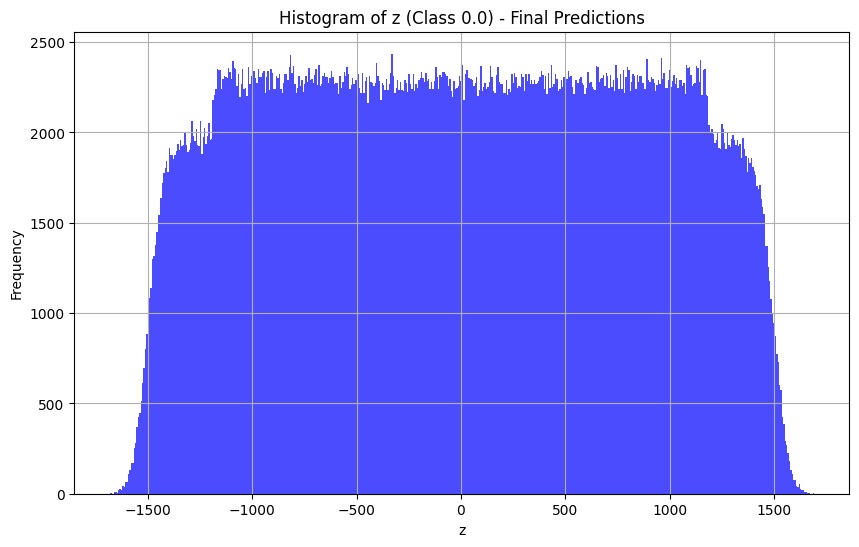

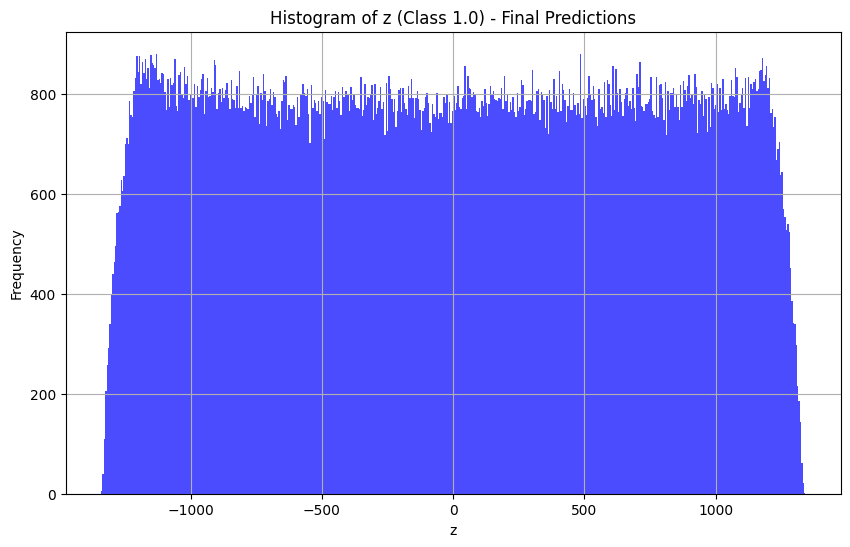

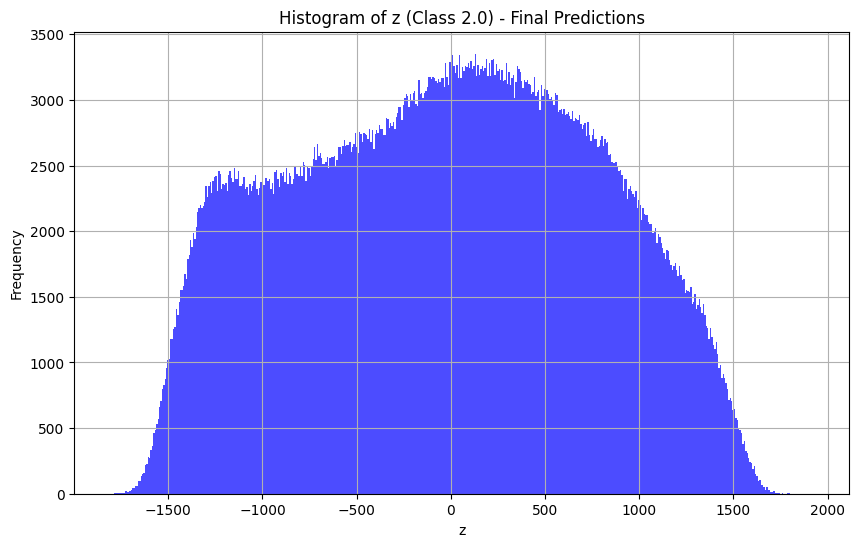

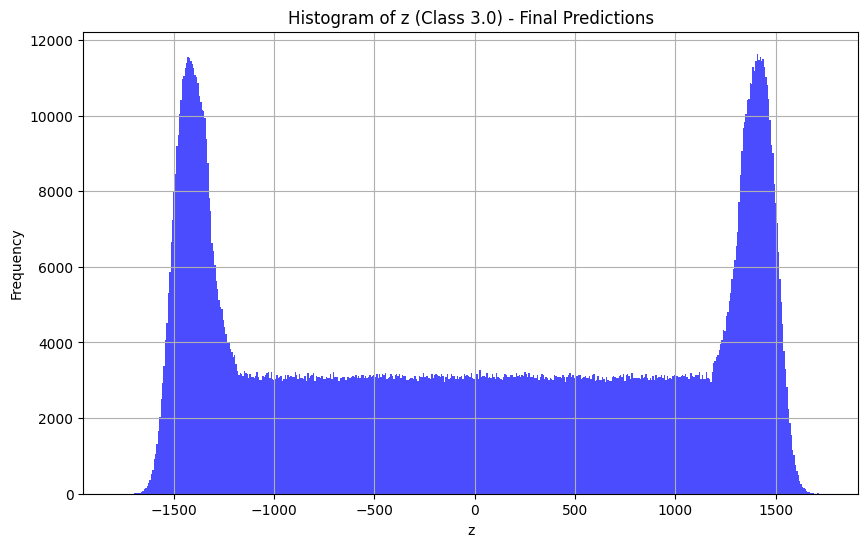

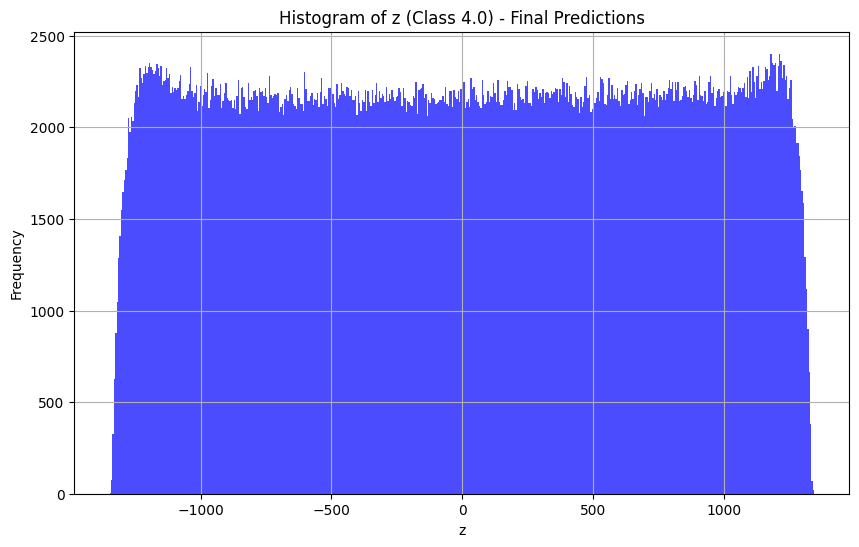

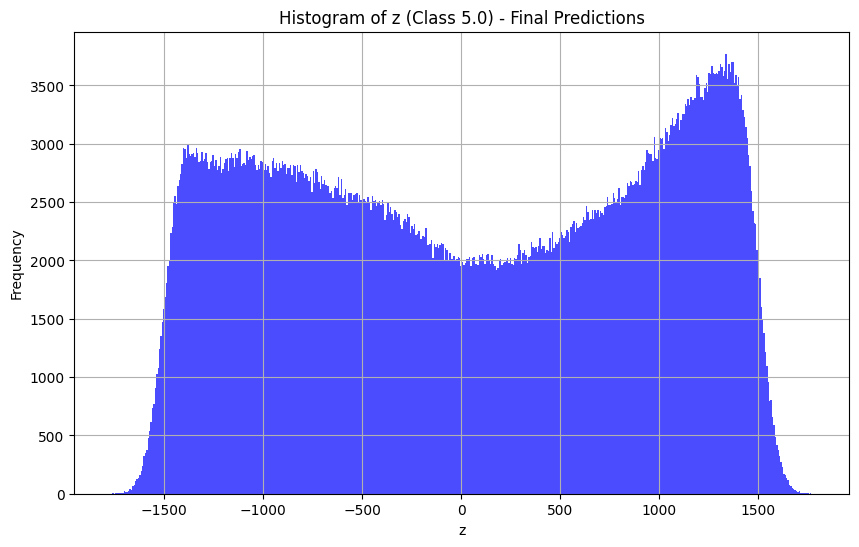

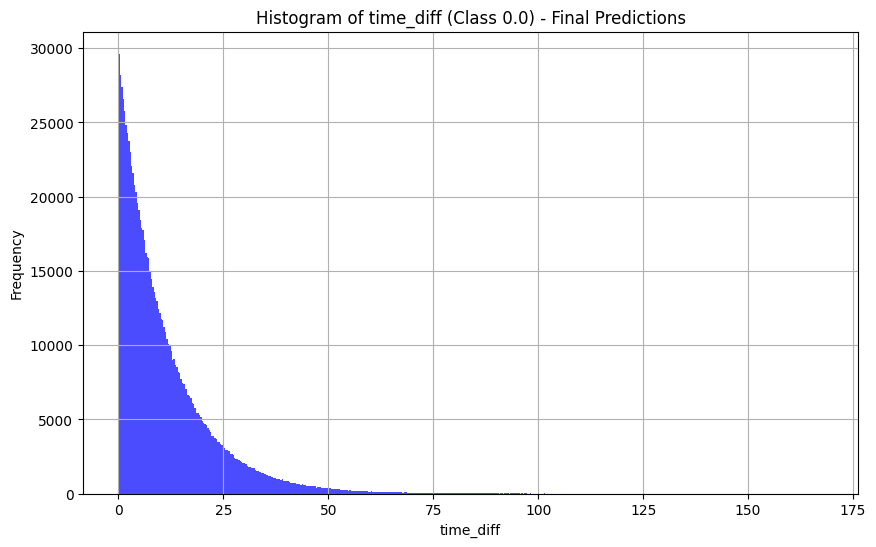

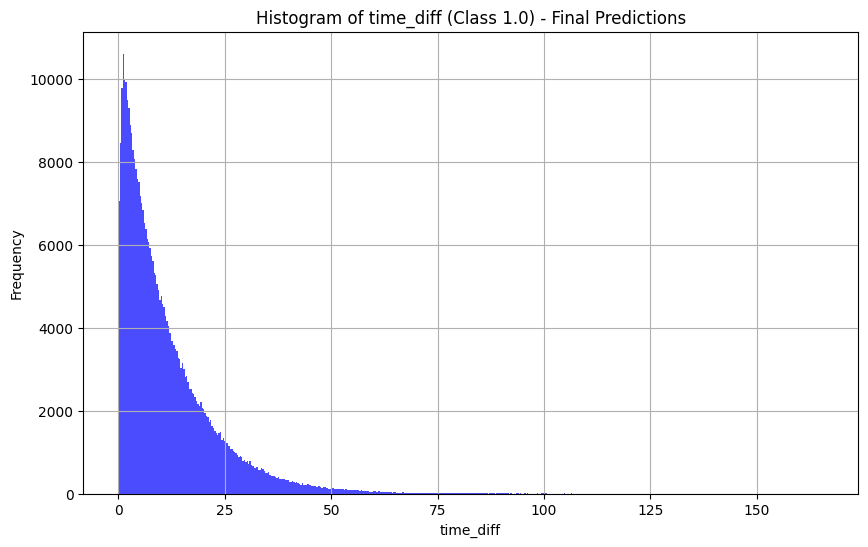

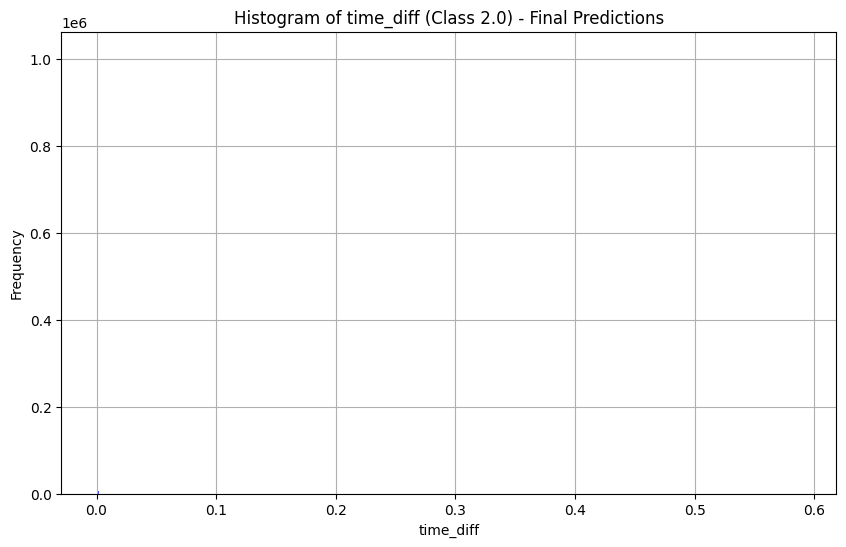

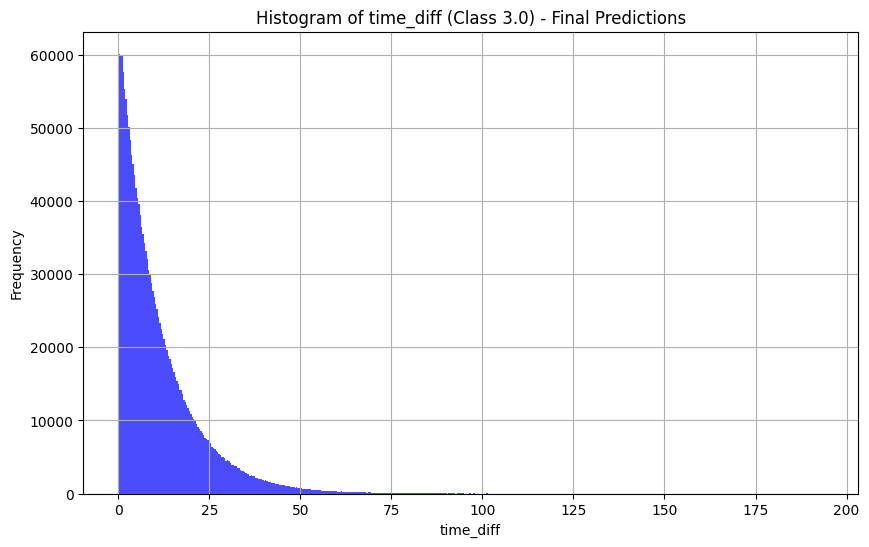

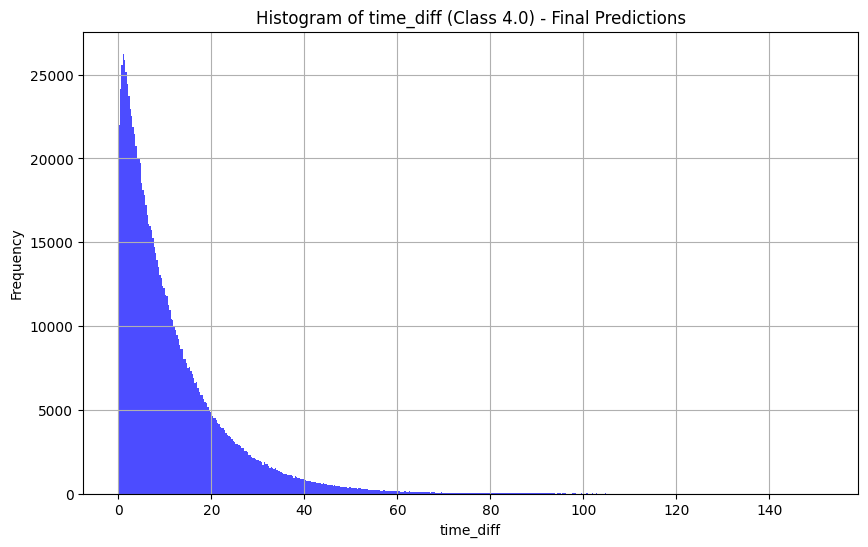

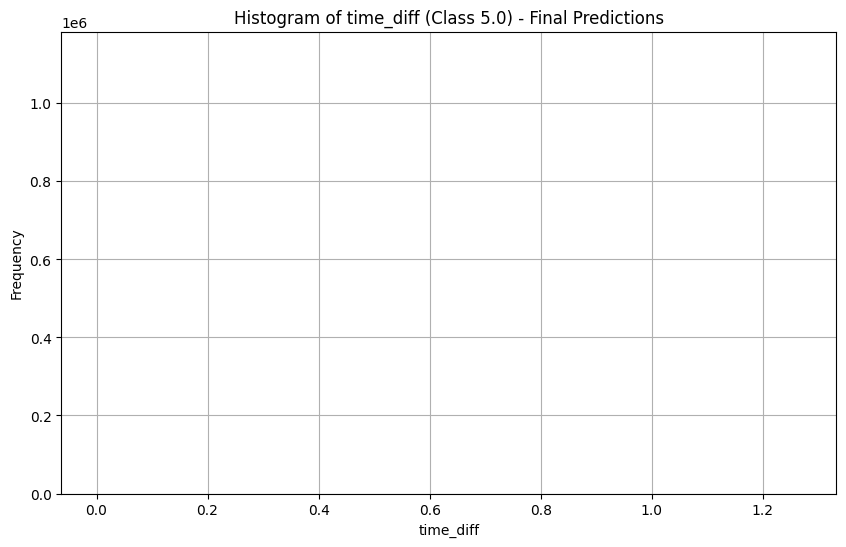

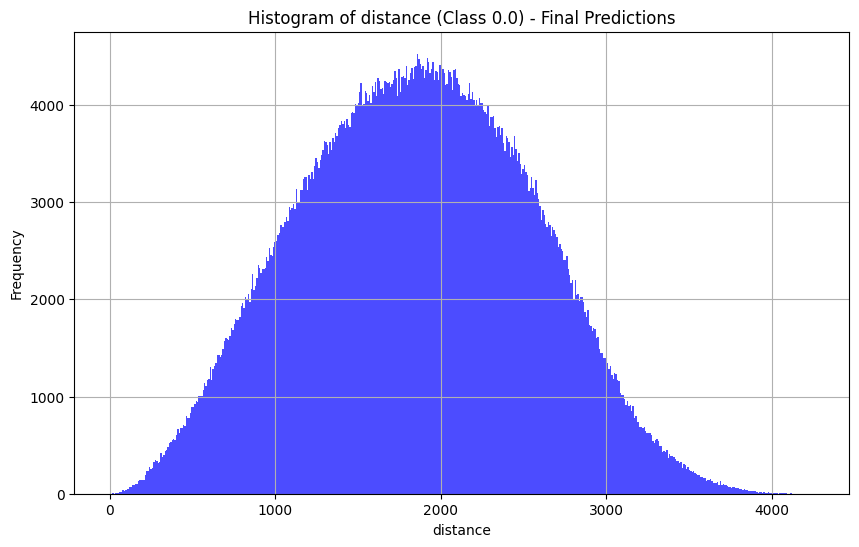

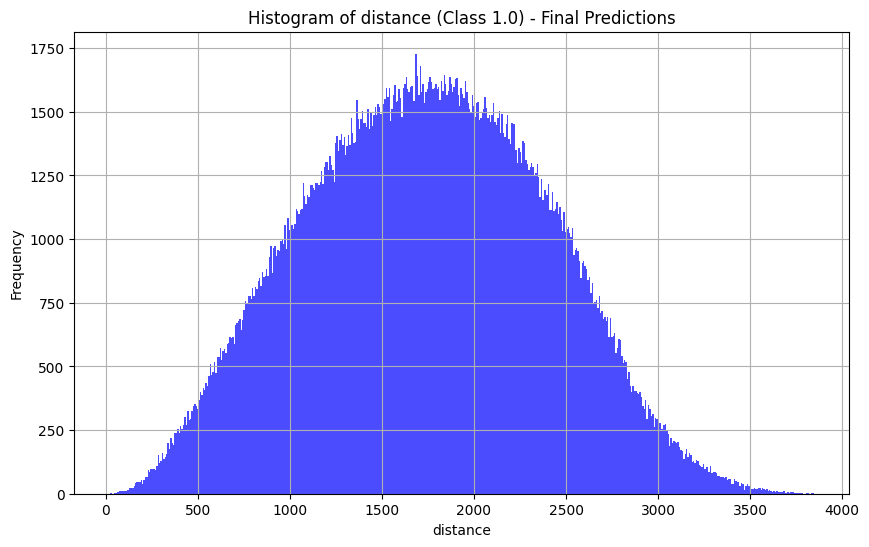

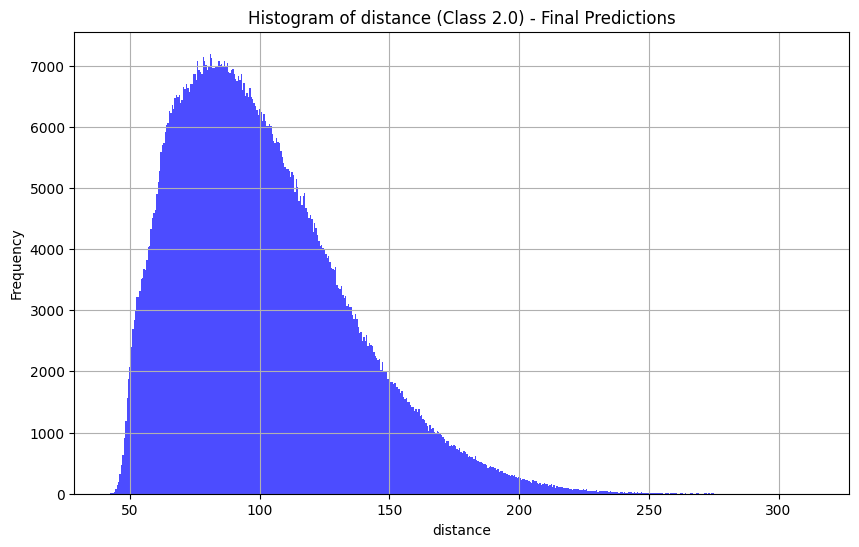

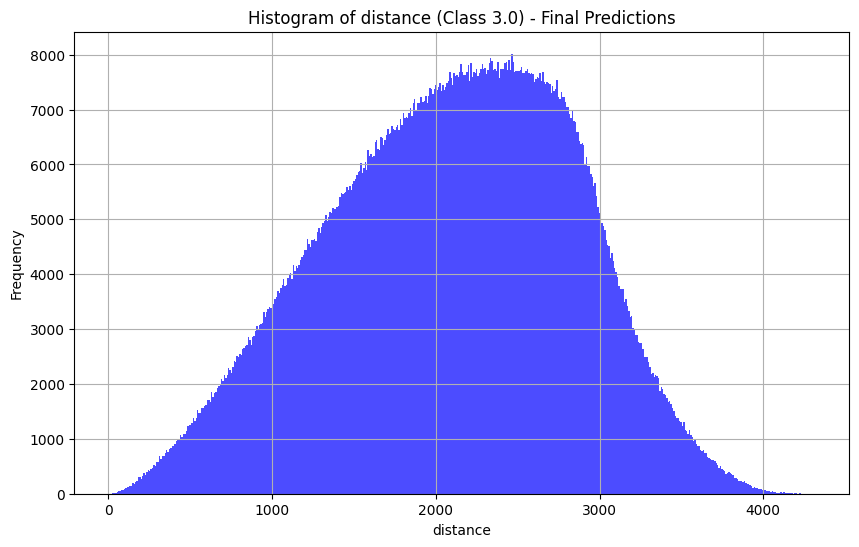

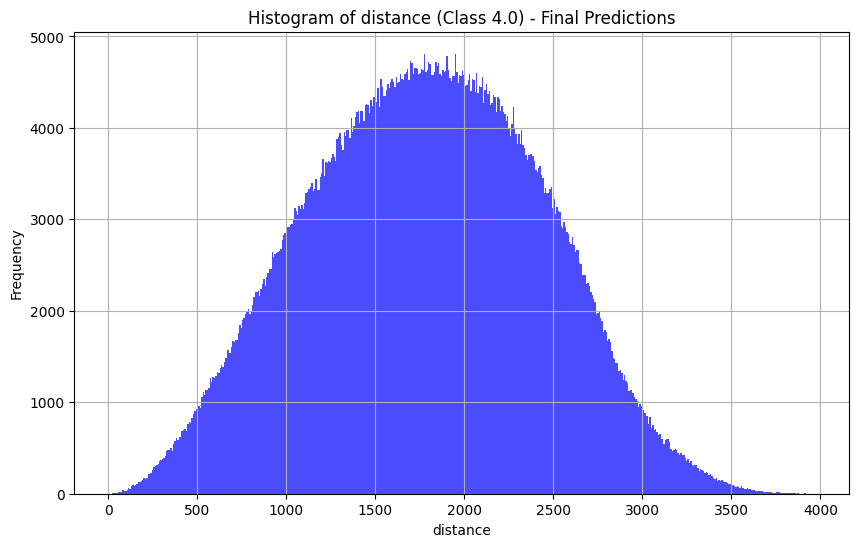

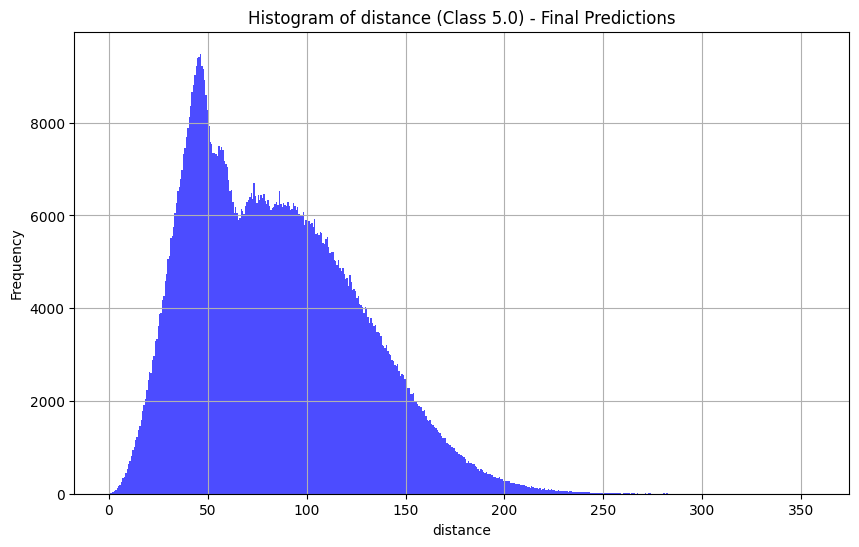

In [ ]:
# Plot for final predictions
plot_histograms(combined_df, y_pred, "Final Predictions", feature_names)

In [ ]:
# Plot histograms for individual models and final predictions
def plot_r2(X, predictions, model_name):

    # Ensure X is a NumPy array
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()

    for class_label in np.unique(predictions):
            plt.figure(figsize=(10, 6))
            
            # Filter the data for the current class
            class_data = X[predictions == class_label, 1]
            # Compute r^2
            data_sq = class_data ** 2
            
            # Plot histogram for the current feature and class
            plt.hist(data_sq, bins=500, alpha=0.7, color='blue')
            plt.title(f'Histogram of $r^2$ (Class {class_label}) - {model_name}')
            plt.xlabel('$r^2$')
            plt.ylabel('Frequency')
            plt.grid(True)
            plt.show()

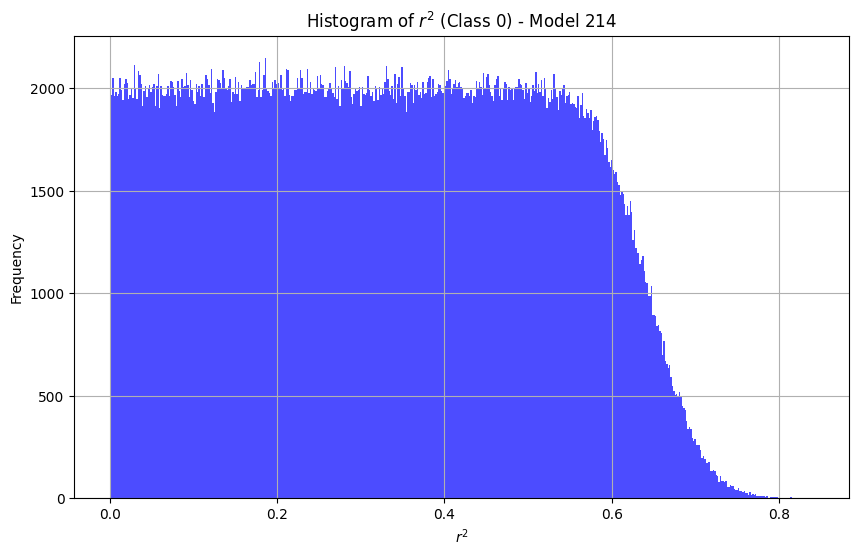

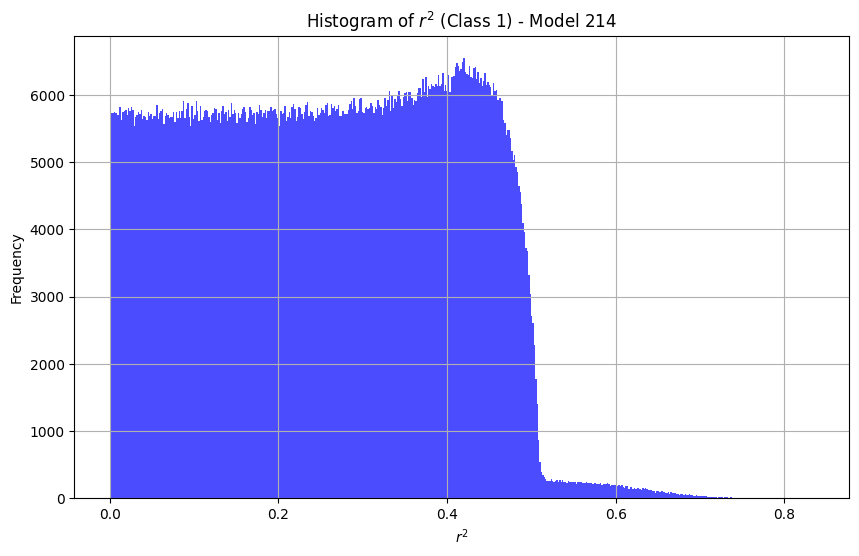

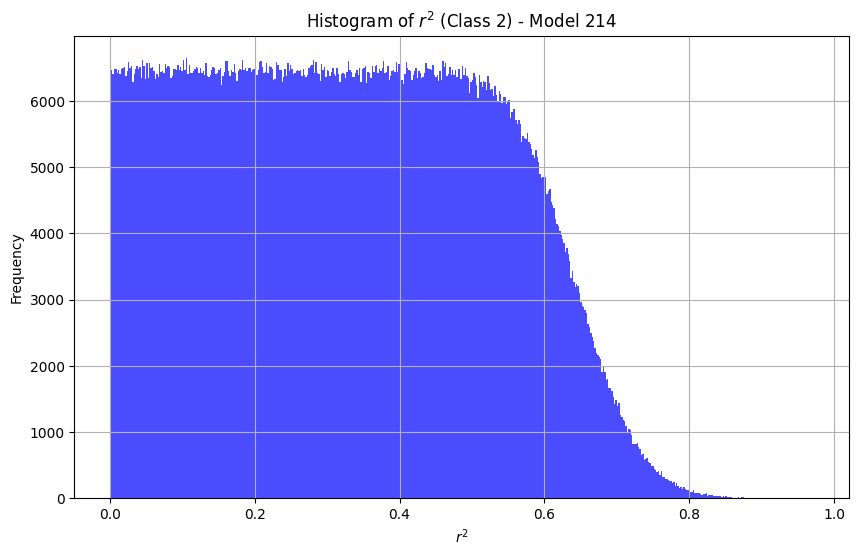

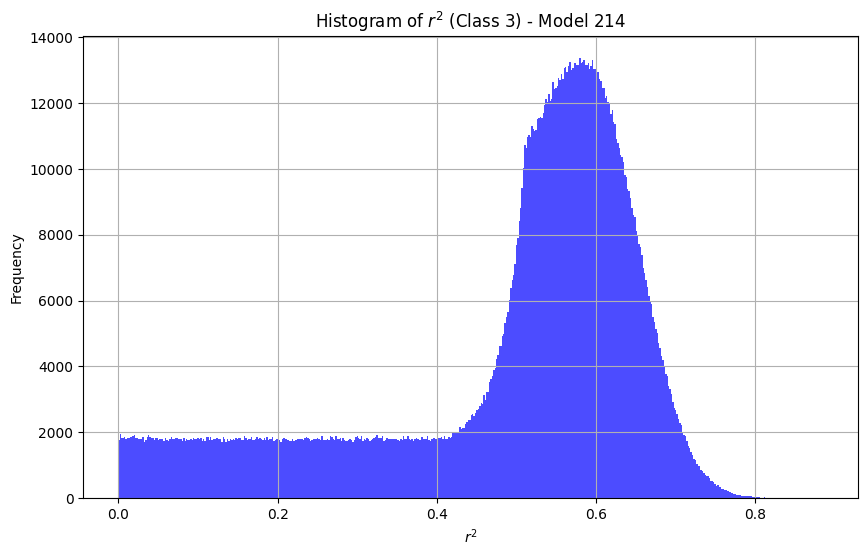

In [ ]:
plot_r2(X_test, y_pred, model_name='Model 214')

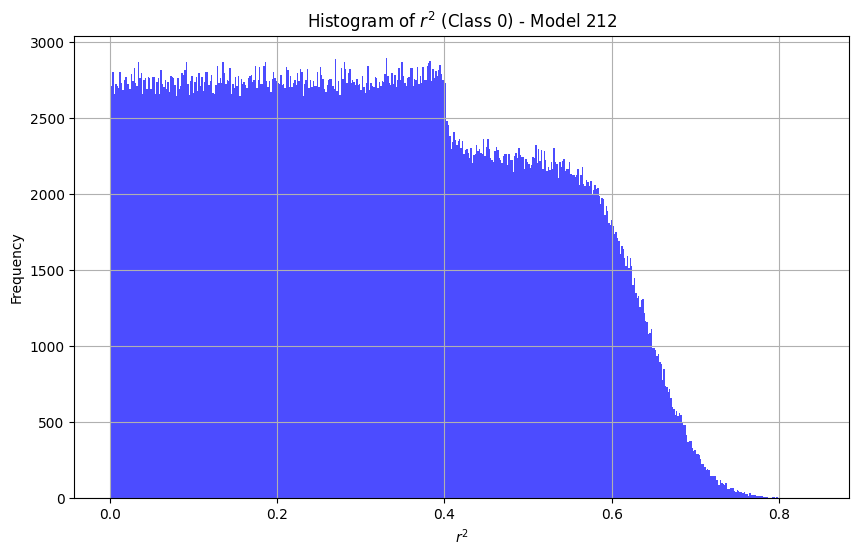

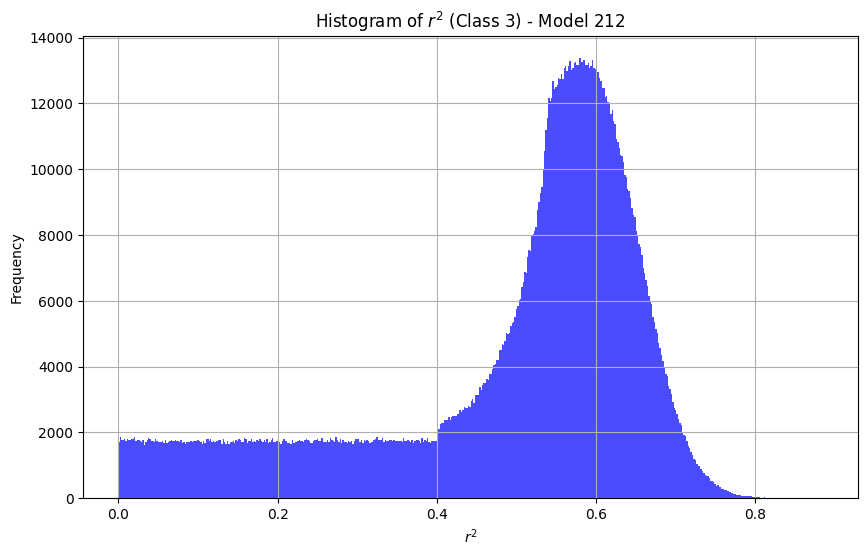

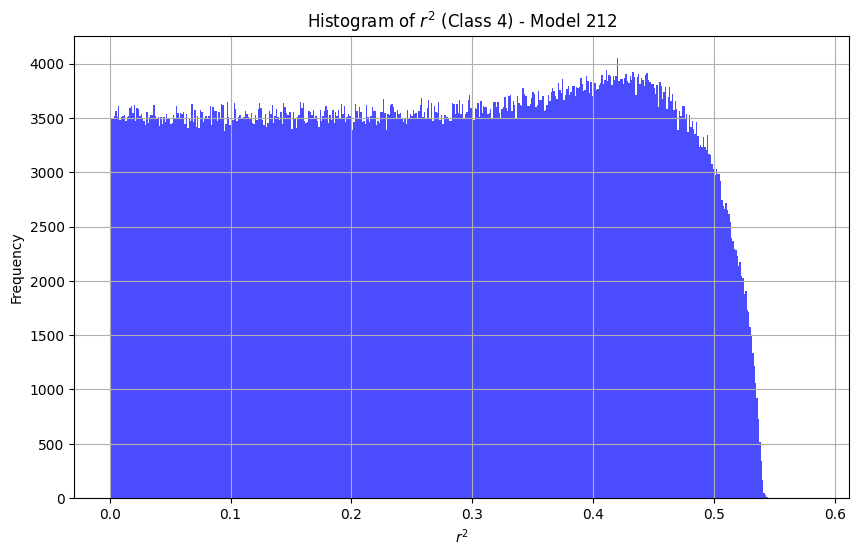

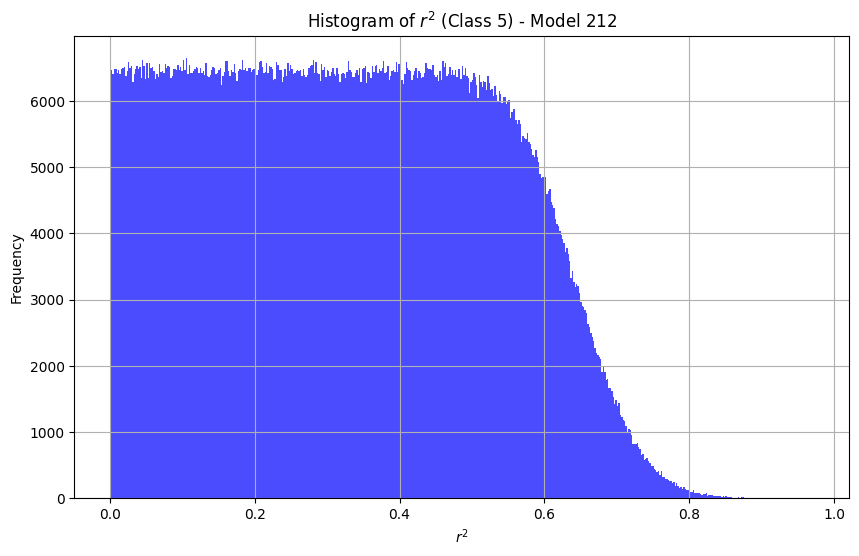

In [ ]:
plot_r2(X_test, model2_pred, model_name='Model 212')

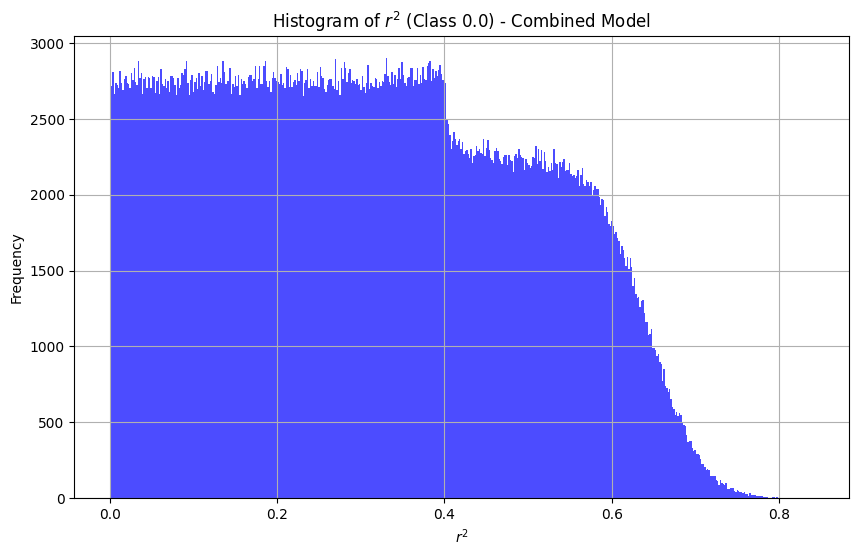

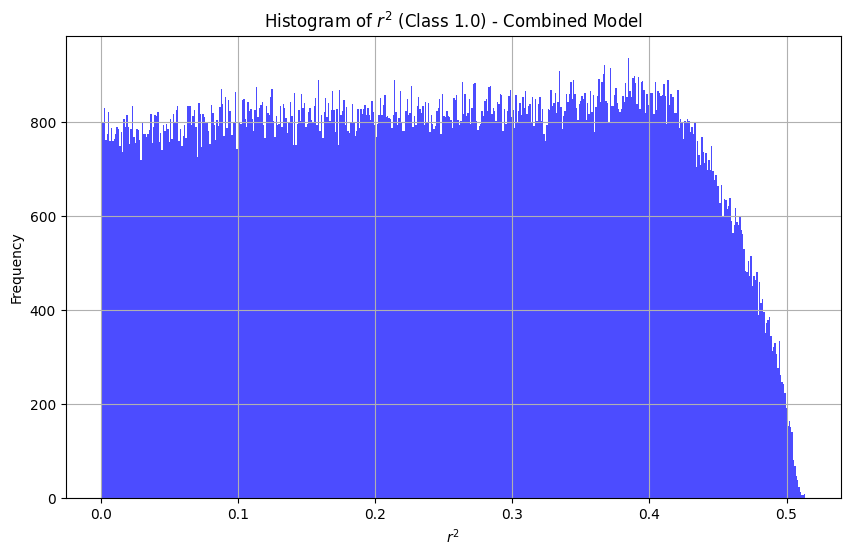

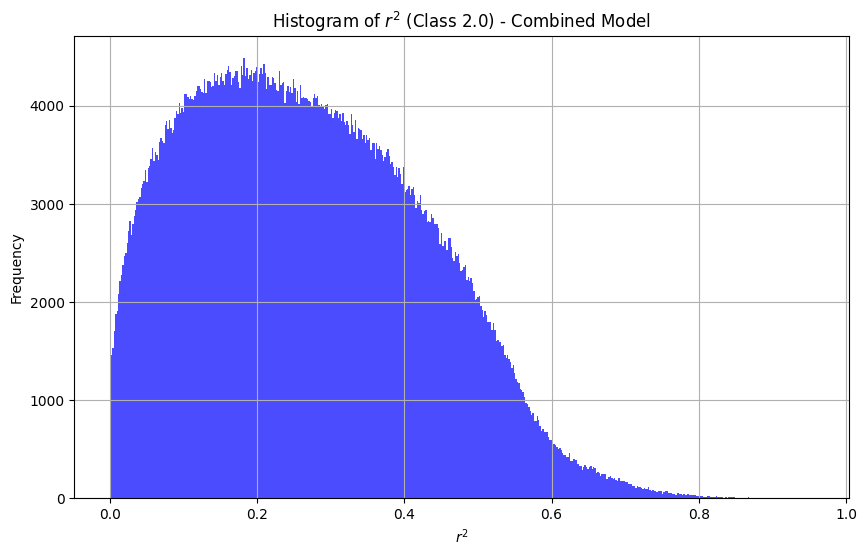

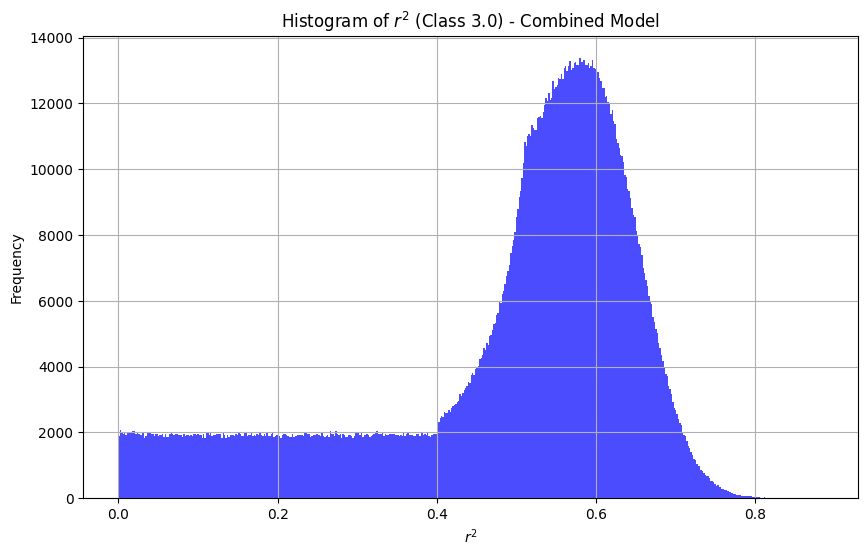

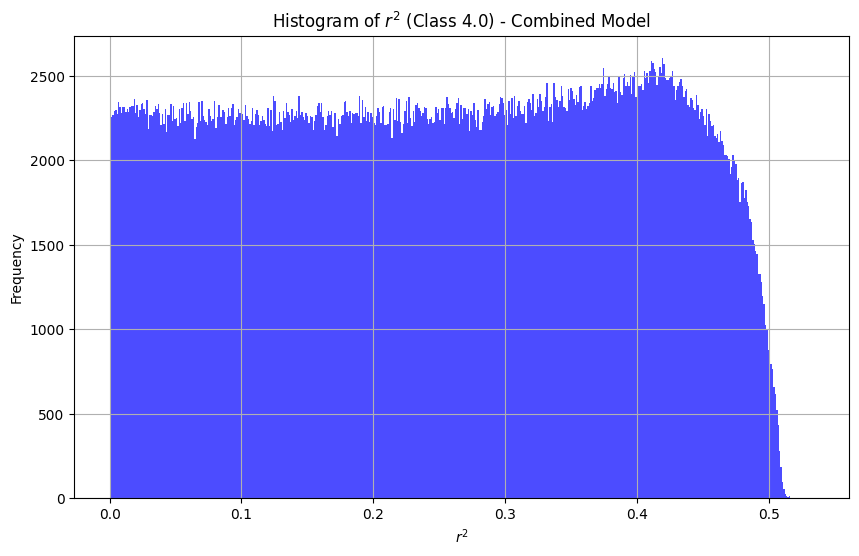

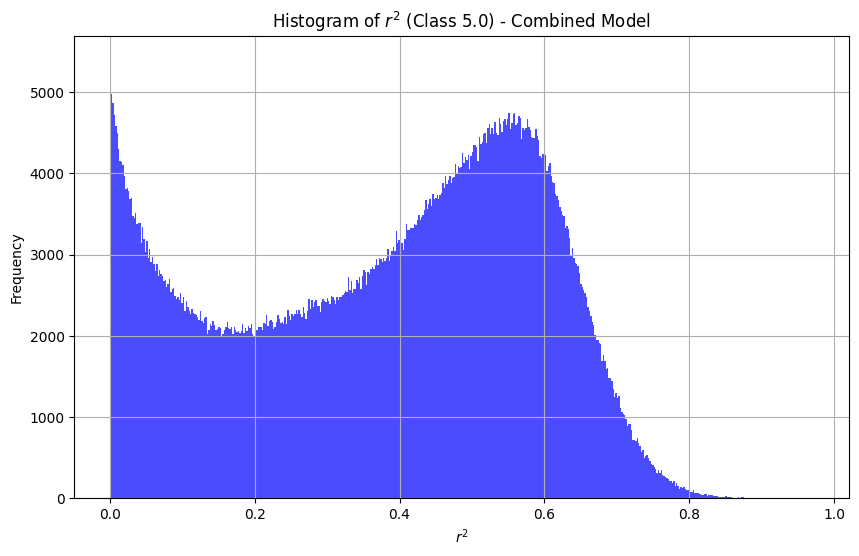

: 

In [ ]:
plot_r2(X_test, y_pred, model_name='Combined Model')